In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install nfstream

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.0/195.0 kB 17.9 MB/s eta 0:00:00


In [ ]:
from nfstream import NFStreamer
import pandas as pd

normal_flows = NFStreamer(source='/content/drive/MyDrive/normal_traffic.pcap').to_pandas()
normal_flows['Label'] = 0

attack_flows = NFStreamer(source='/content/drive/MyDrive/attack_traffic.pcap').to_pandas()
attack_flows['Label'] = 1

real_traffic = pd.concat([normal_flows, attack_flows], ignore_index=True)

print("Shape:", real_traffic.shape)
print(real_traffic['Label'].value_counts())

Shape: (792, 39)
Label
1    517
0    275
Name: count, dtype: int64


In [ ]:
import numpy as np

df_behavior = real_traffic.copy()

df_behavior['packets_per_second'] = df_behavior['bidirectional_packets'] / (df_behavior['bidirectional_duration_ms'] / 1000 + 0.001)

df_behavior['avg_packet_size'] = df_behavior['bidirectional_bytes'] / (df_behavior['bidirectional_packets'] + 0.001)

ip_counts = df_behavior['src_ip'].value_counts()
df_behavior['src_ip_frequency'] = df_behavior['src_ip'].map(ip_counts)

df_behavior['byte_ratio'] = df_behavior['src2dst_bytes'] / (df_behavior['dst2src_bytes'] + 0.001)

df_behavior['packet_ratio'] = df_behavior['src2dst_packets'] / (df_behavior['dst2src_packets'] + 0.001)

df_behavior['is_short_connection'] = (df_behavior['bidirectional_duration_ms'] < 100).astype(int)

print("Behavioral features created.")
print(df_behavior[['packets_per_second', 'avg_packet_size', 'src_ip_frequency',
                    'byte_ratio', 'packet_ratio', 'is_short_connection', 'Label']].head(10))

Behavioral features created.
   packets_per_second  avg_packet_size  src_ip_frequency    byte_ratio  \
0            0.160524        56.161987                 1  1.067481e+00   
1            0.123210       121.984752                 1  9.760000e+05   
2            0.123210       141.982252                 1  1.136000e+06   
3            0.753733       538.658117                 1  7.551590e-01   
4            0.094570       121.984752                 1  9.760000e+05   
5            0.094570       141.982252                 1  1.136000e+06   
6         1000.000000        53.946054                 1  5.400000e+04   
7          647.058824        69.993637               174  9.493647e-01   
8          916.666667        76.538497               174  8.029961e-01   
9          846.153846        75.084083               174  8.314837e-01   

   packet_ratio  is_short_connection  Label  
0      0.999833                    0      0  
1   8000.000000                    0      0  
2   8000.000000   

In [ ]:

features_with_port = [
    'bidirectional_duration_ms', 'bidirectional_packets', 'bidirectional_bytes',
    'src2dst_duration_ms', 'src2dst_packets', 'src2dst_bytes',
    'dst2src_duration_ms', 'dst2src_packets', 'dst2src_bytes',
    'src_port', 'dst_port', 'protocol'
]

features_behavioral = [
    'packets_per_second', 'avg_packet_size', 'src_ip_frequency',
    'byte_ratio', 'packet_ratio', 'is_short_connection',
    'bidirectional_duration_ms', 'bidirectional_packets', 'bidirectional_bytes',
    'protocol'
]

def clean_dataset(df, feature_cols):
    data = df[feature_cols + ['Label']].copy()
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.dropna(inplace=True)
    return data

df_with_port = clean_dataset(df_behavior, features_with_port)
df_behavioral_only = clean_dataset(df_behavior, features_behavioral)

print("With port dataset:", df_with_port.shape)
print("Behavioral-only dataset:", df_behavioral_only.shape)

With port dataset: (792, 13)
Behavioral-only dataset: (792, 11)


In [ ]:
from sklearn.model_selection import train_test_split

def split_data(data):
    X = data.drop('Label', axis=1)
    y = data['Label']
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_port, X_test_port, y_train_port, y_test_port = split_data(df_with_port)
X_train_beh, X_test_beh, y_train_beh, y_test_beh = split_data(df_behavioral_only)

print("With-port train/test:", X_train_port.shape, X_test_port.shape)
print("Behavioral-only train/test:", X_train_beh.shape, X_test_beh.shape)

With-port train/test: (633, 12) (159, 12)
Behavioral-only train/test: (633, 10) (159, 10)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import time
import warnings
warnings.filterwarnings('ignore')

def get_models():
    return {
        'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
        'XGBoost':              XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0),
        'Decision Tree':        DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        'Logistic Regression':  LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1),
        'Linear SVM':           LinearSVC(class_weight='balanced', max_iter=1000, random_state=42),
    }

def train_and_evaluate(X_train, X_test, y_train, y_test, label):
    results = []
    print(f"\n{'='*60}\nTraining on: {label}\n{'='*60}")
    for name, model in get_models().items():
        start = time.time()
        model.fit(X_train, y_train)
        train_time = round(time.time() - start, 2)

        y_pred = model.predict(X_test)

        precision = round(precision_score(y_test, y_pred, zero_division=0) * 100, 2)
        recall    = round(recall_score(y_test, y_pred, zero_division=0) * 100, 2)
        f1        = round(f1_score(y_test, y_pred, zero_division=0) * 100, 2)
        fp        = int(sum((y_pred == 1) & (y_test == 0)))
        tn        = int(sum((y_pred == 0) & (y_test == 0)))
        fpr       = round(fp / (fp + tn) * 100, 2) if (fp + tn) > 0 else 0

        results.append({
            'Feature Set': label, 'Model': name, 'Precision %': precision,
            'Recall %': recall, 'F1-Score %': f1, 'FPR %': fpr,
            'False Positives': fp, 'Train Time (s)': train_time
        })
        print(f"  {name:<22} F1: {f1:>6}% | FPR: {fpr:>5}% | Time: {train_time}s")
    return results

results_with_port = train_and_evaluate(X_train_port, X_test_port, y_train_port, y_test_port, 'With Port')
results_behavioral = train_and_evaluate(X_train_beh, X_test_beh, y_train_beh, y_test_beh, 'Behavioral Only')

all_results = results_with_port + results_behavioral


Training on: With Port
  Random Forest          F1:  100.0% | FPR:   0.0% | Time: 0.24s
  XGBoost                F1:  100.0% | FPR:   0.0% | Time: 0.07s
  Decision Tree          F1:  100.0% | FPR:   0.0% | Time: 0.0s
  K-Nearest Neighbours   F1:  99.52% | FPR:  1.82% | Time: 0.01s
  Logistic Regression    F1:  100.0% | FPR:   0.0% | Time: 1.91s
  Linear SVM             F1:  98.58% | FPR:  5.45% | Time: 0.01s

Training on: Behavioral Only
  Random Forest          F1:  100.0% | FPR:   0.0% | Time: 0.25s
  XGBoost                F1:  100.0% | FPR:   0.0% | Time: 0.03s
  Decision Tree          F1:  100.0% | FPR:   0.0% | Time: 0.0s
  K-Nearest Neighbours   F1:  100.0% | FPR:   0.0% | Time: 0.0s
  Logistic Regression    F1:  100.0% | FPR:   0.0% | Time: 1.23s
  Linear SVM             F1:  99.52% | FPR:  1.82% | Time: 0.01s


In [ ]:
results_df = pd.DataFrame(all_results)
pivot_f1 = results_df.pivot(index='Model', columns='Feature Set', values='F1-Score %')
pivot_fpr = results_df.pivot(index='Model', columns='Feature Set', values='FPR %')

print("F1-SCORE COMPARISON:")
print(pivot_f1)
print("\nFALSE POSITIVE RATE COMPARISON:")
print(pivot_fpr)

F1-SCORE COMPARISON:
Feature Set           Behavioral Only  With Port
Model                                           
Decision Tree                  100.00     100.00
K-Nearest Neighbours           100.00      99.52
Linear SVM                      99.52      98.58
Logistic Regression            100.00     100.00
Random Forest                  100.00     100.00
XGBoost                        100.00     100.00

FALSE POSITIVE RATE COMPARISON:
Feature Set           Behavioral Only  With Port
Model                                           
Decision Tree                    0.00       0.00
K-Nearest Neighbours             0.00       1.82
Linear SVM                       1.82       5.45
Logistic Regression              0.00       0.00
Random Forest                    0.00       0.00
XGBoost                          0.00       0.00


In [ ]:
rf_behavioral = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_behavioral.fit(X_train_beh, y_train_beh)

feature_importance_beh = pd.DataFrame({
    'Feature': X_train_beh.columns,
    'Importance': rf_behavioral.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance — Behavioral Model (NO port information):")
print(feature_importance_beh)

Feature Importance — Behavioral Model (NO port information):
                     Feature  Importance
2           src_ip_frequency    0.304159
1            avg_packet_size    0.270313
3                 byte_ratio    0.117400
4               packet_ratio    0.115937
8        bidirectional_bytes    0.092260
7      bidirectional_packets    0.060258
6  bidirectional_duration_ms    0.021882
0         packets_per_second    0.015307
5        is_short_connection    0.002092
9                   protocol    0.000392


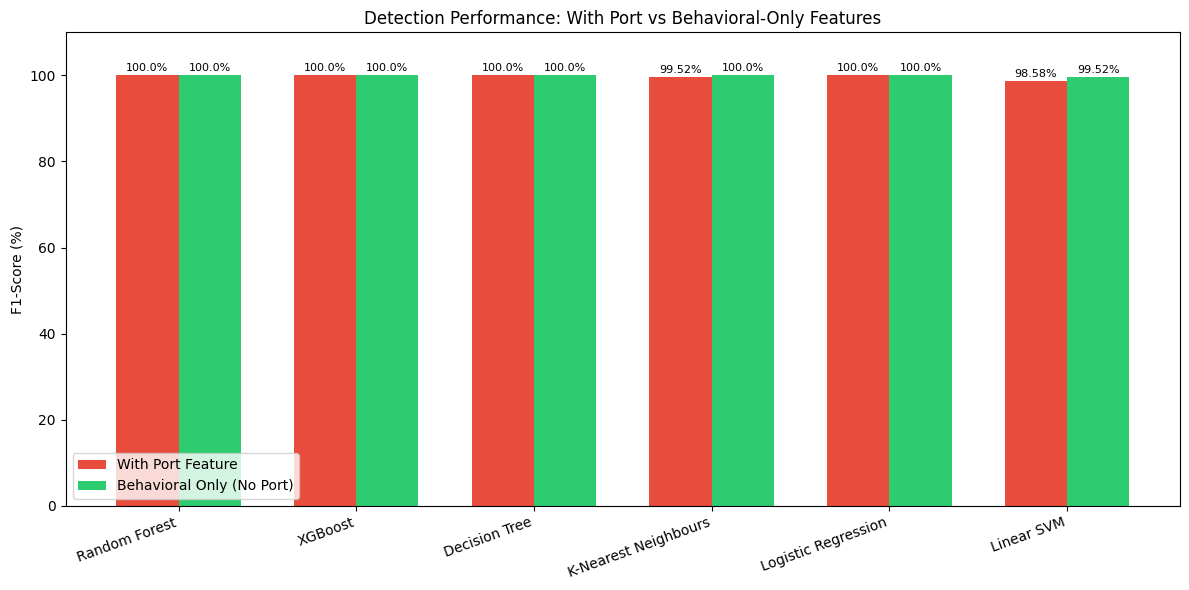

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models_list = list(get_models().keys())
port_f1 = [results_df[(results_df['Model']==m) & (results_df['Feature Set']=='With Port')]['F1-Score %'].values[0] for m in models_list]
beh_f1 = [results_df[(results_df['Model']==m) & (results_df['Feature Set']=='Behavioral Only')]['F1-Score %'].values[0] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, port_f1, width, label='With Port Feature', color='#e74c3c')
bars2 = ax.bar(x + width/2, beh_f1, width, label='Behavioral Only (No Port)', color='#2ecc71')

ax.set_ylabel('F1-Score (%)')
ax.set_title('Detection Performance: With Port vs Behavioral-Only Features')
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=20, ha='right')
ax.set_ylim(0, 110)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height()}%', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height()}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('port_vs_behavioral.png', dpi=150)
plt.show()

In [ ]:
import joblib
joblib.dump(rf_behavioral, 'bruteforce_model.pkl')
joblib.dump(list(X_train_beh.columns), 'feature_names.pkl')
from google.colab import files
files.download('bruteforce_model.pkl')
files.download('feature_names.pkl')
print("Done")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done
